In [ ]:
from google.colab import drive
drive.mount('/content/drive')

! pip install jaxopt
! pip install corner
! pip install emcee
!pip install blackjax jax==0.7.2 jaxlib==0.7.2

import os
# os.environ["JAX_ENABLE_X64"] = "True"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
print(os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"])

path = '/content/drive/MyDrive/SchwarMAX-analytic/'

import sys
sys.path.append(path)

from model_bar import *
from likelihoods_bar import *
from utils import *
from sample_from_density import sample_from_density_grid

import jax
# jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.numpy.linalg as jnn
import jaxopt

import pandas as pd
import numpy as np
import scipy as sp
import pickle
from tqdm import tqdm

import emcee
import corner
import matplotlib.pyplot as plt

import blackjax
from blackjax.smc.resampling import systematic
import time

from constants import EPSILON

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of blackjax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 22.3 MB/s eta 0:00:00
  Attempting uninstall: jaxopt
    Found existing installation: jaxopt 0.8.5
    Uninstalling jaxopt-0.8.5:
      Successfully uninstalled jaxopt-0.8.5
0.95


In [ ]:
path = '/content/drive/MyDrive/SchwarMAX-analytic/'
filename = 'mock_Nbody_bar_XY_withRot_Nbins600_beta5_gamma140_D50_gal2.pkl'
# filename = 'mock_Nbody_bar_XY_withRot_gal2_Nbins1000.pkl'
dict_data = get_dict_data_bootstrap(path, filename, n_samples = 7_500)

def log_prior(theta,):
    if (7 < theta[0] < 12) and (8 < theta[1] < 12) and (-1 < theta[2] < 2) and (-1 < theta[3] < 1) and (-1 < theta[4] < 1)\
    and (0 <= theta[5] < jnp.pi) and (0 <= theta[6] < jnp.pi/2) and (0 <= theta[7] < jnp.pi):
        return 0.0  # log(1) = 0 for uniform prior
    return -np.inf  # log(0) = -inf for out-of-bounds

def log_prob(theta,):
    # print(theta)
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    ll = logl_density(theta, dict_data, dict_data['total_bins'])

    return ll + lp

ndim = 8
nwalkers = 16  # must be >= 2 * ndim

# Initialize walkers around ground truth
# p0 = np.array([ground_truth[k] for k in param_names])
p0 = np.array([10.5, 10, 0.8, 0., 0.5, jnp.pi/10, jnp.pi/4, 3.5*jnp.pi/4])
# initial_pos = p0 + 1e-1 * np.random.randn(nwalkers, ndim)
np.random.seed(42)
initial_pos = p0 + np.random.uniform(-0.3, 0.3, (nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial_pos, 500, progress=True)

samples = sampler.get_chain(discard=200, flat=True)


params_bestfit = np.percentile(samples, axis=0, q=50)
logl_val = logl_density(params_bestfit, dict_data, dict_data['total_bins'])
print('Best-fit logL projection', logl_val)#

dict_data['logl_density_max'] = logl_val

logM_disc_best_fit, logM_bulge_best_fit, \
logRd_disc_best_fit, logHs_disc_best_fit, logRs_bulge_best_fit, \
alpha_best_fit, beta_best_fit, gamma_best_fit = params_bestfit
# logMhalo_best_fit, logrho0_best_fit, logM_bulge_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bulge_best_fit,\
#       alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit = (11.8, 8.8, 10.4, 1.2, 0.45, -0.24, -0.1, 30*np.pi/180, 20*np.pi/180, 0*np.pi/180, 0)

print('logM_disc_best_fit',logM_disc_best_fit)
print('logM_bulge_best_fit',logM_bulge_best_fit)
print('logRd_disc_best_fit',logRd_disc_best_fit)
print('logHs_disc_best_fit',logHs_disc_best_fit)
print('logRs_bulge_best_fit',logRs_bulge_best_fit)
print('alpha_best_fit',alpha_best_fit * 180 / np.pi)
print('beta_best_fit',beta_best_fit * 180 / np.pi)
print('gamma_best_fit',gamma_best_fit * 180 / np.pi)

ground_truth = [
    10.779253,
    # 11.9,
    logM_disc_best_fit,
    logM_bulge_best_fit,
    0.8970275,
    # 1.276,
    logRd_disc_best_fit,
    logHs_disc_best_fit,
    logRs_bulge_best_fit,
    alpha_best_fit, #  10 * np.pi/180,
    beta_best_fit,
    gamma_best_fit,
    0.,
    1.5,

    0.6, # sigma_xy model term
]
# ground_truth = [
#     10.36,
#     10.77,
#     10.,
#     1.18,
#     0.63,
#     -0.14,
#     0.19,
#     0.2,
#     0.35,
#     2.78,
#     -0.06,
#     1.36,
#     0.68
# ]

# # Test 1: your proven working vmap
# vmap_direct = jax.vmap(logl_angular_input_bootstrap, in_axes=(0, None, None, None))
# test_params = jnp.array([ground_truth]*4)
# %time vmap_direct(test_params, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot']).block_until_ready()
# %time vmap_direct(test_params, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot']).block_until_ready()

100%|██████████| 500/500 [00:04<00:00, 104.58it/s]

Best-fit logL projection -3.0294347
logM_disc_best_fit 10.707299481868056
logM_bulge_best_fit 9.894751415813626
logRd_disc_best_fit 0.5269745946149236
logHs_disc_best_fit -0.1715840884362848
logRs_bulge_best_fit -0.33835280724027117
alpha_best_fit 19.289395056595925
beta_best_fit 8.869447991530782
gamma_best_fit 141.6219216170791


 11%|█         | 1/9 [01:15<10:05, 75.71s/it]

L/M= 0.3467368504525316 -4094.3655


 22%|██▏       | 2/9 [01:19<03:55, 33.62s/it]

L/M= 0.436515832240166 -1751.3918


 33%|███▎      | 3/9 [01:24<02:01, 20.18s/it]

...

 89%|████████▉ | 8/9 [00:33<00:04,  4.15s/it]

amplifier= 9.549925860214358 -446.66922


100%|██████████| 9/9 [00:37<00:00,  4.15s/it]

amplifier= 12.02264434617413 -1047.8877


[Text(0.5, 0, ' log10(amplifier)')]

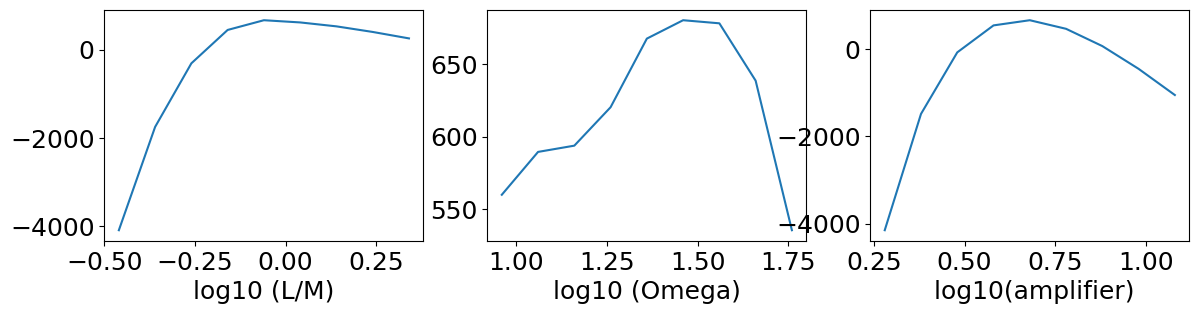

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(14,3))

# reader = emcee.backends.HDFBackend(path + '/backend_0328_Nbins1000_withDens.csv', read_only=True)
# wholechain = reader.get_chain(discard=0, flat=False)
# logprob = reader.get_log_prob(discard=0, flat=False)
# posterior = wholechain[100:, (np.isfinite(logprob[-1, :]) & np.isfinite(logprob[50, :])), :]
# posterior = posterior.reshape(-1, posterior.shape[-1])
# emcee_mean = np.median(posterior, axis=0)
# emcee_std = np.std(posterior, axis=0)
# prior_center = emcee_mean
# print(prior_center)

logL_ls = []
for i in tqdm(range (0, 9)):
  # params_i = [
  #   # 11.9,
  #   10.8,
  #   logM_disc_best_fit,
  #   logM_bulge_best_fit,
  #   # jnp.log10(19).item(),
  #   0.8970275,
  #   logRd_disc_best_fit,
  #   logHs_disc_best_fit,
  #   logRs_bulge_best_fit,
  #   10*jnp.pi/180,
  #   beta_best_fit,
  #   # gamma_best_fit,
  #   140*jnp.pi/180,
  #   0.,
  #   1.5,

  #   0.5,
  # ]
  params_i = [
    10.36,
    10.77,
    10.,
    1.18,
    0.63,
    -0.14,
    0.19,
    0.2,
    0.35,
    2.78,
    -0.06,
    1.36,
    0.68
  ]
  # params_i = prior_center.copy()
  params_i[-3] = params_i[-3] + (i-4)/10
  logL = logl_angular_input_bootstrap(params_i, dict_data, dict_data['total_bins'])
  logL.block_until_ready()  # Ensure computation finishes before timing
  print('L/M=', 10**params_i[-3], logL)
  logL_ls.append(logL)

ax[0].plot(np.arange(-4,5)/10 + ground_truth[-3], logL_ls - np.amin(np.isfinite(logL_ls)))
ax[0].set(xlabel = 'log10 (L/M)')

logL_ls = []
for i in tqdm(range (0, 9)):
  # params_i = [
  #   # 11.9,
  #   10.78,
  #   logM_disc_best_fit,
  #   logM_bulge_best_fit,
  #   # jnp.log10(19).item(),
  #   0.9,
  #   logRd_disc_best_fit,
  #   logHs_disc_best_fit,
  #   logRs_bulge_best_fit,
  #   alpha_best_fit,
  #   beta_best_fit,
  #   gamma_best_fit,
  #   0.,
  #   1.5,

  #   0.5,
  # ]
  params_i = [
    10.36,
    10.77,
    10.,
    1.18,
    0.63,
    -0.14,
    0.19,
    0.2,
    0.35,
    2.78,
    -0.06,
    1.36,
    0.68
  ]
  # params_i = prior_center.copy()
  params_i[-2] = params_i[-2] + (i-4)/10
  logL = logl_angular_input_bootstrap(params_i, dict_data, dict_data['total_bins'])
  logL.block_until_ready()  # Ensure computation finishes before timing
  logL_ls.append(logL)
  print('Omega=', 10**params_i[-2], logL)

ax[1].plot(np.arange(-4,5)/10 + ground_truth[-2], logL_ls - np.amin(np.isfinite(logL_ls)))
ax[1].set(xlabel = 'log10 (Omega)')

logL_ls = []
for i in tqdm(range (0, 9)):
  # params_i = [
  #   # 11.9,
  #   10.78,
  #   logM_disc_best_fit,
  #   logM_bulge_best_fit,
  #   # jnp.log10(19).item(),
  #   0.9,
  #   logRd_disc_best_fit,
  #   logHs_disc_best_fit,
  #   logRs_bulge_best_fit,
  #   alpha_best_fit,
  #   beta_best_fit,
  #   gamma_best_fit,
  #   0.,
  #   1.5,

  #   0.5,
  # ]
  params_i = [
    10.36,
    10.77,
    10.,
    1.18,
    0.63,
    -0.14,
    0.19,
    0.2,
    0.35,
    2.78,
    -0.06,
    1.36,
    0.68
  ]
  # params_i = prior_center.copy()
  params_i[-1] = params_i[-1] + (i-4)/10
  logL = logl_angular_input_bootstrap(params_i, dict_data, dict_data['total_bins'])
  logL.block_until_ready()  # Ensure computation finishes before timing
  logL_ls.append(logL)
  print('amplifier=', 10**params_i[-1], logL)

ax[2].plot(np.arange(-4,5)/10 + ground_truth[-1], logL_ls - np.amin(np.isfinite(logL_ls)))
ax[2].set(xlabel = ' log10(amplifier)')

In [ ]:
ground_truth = [
    10.779253,
    # 11.9,
    logM_disc_best_fit,
    logM_bulge_best_fit,
    0.8970275,
    # 1.276,
    logRd_disc_best_fit,
    logHs_disc_best_fit,
    logRs_bulge_best_fit,
    alpha_best_fit, #  10 * np.pi/180,
    beta_best_fit,
    gamma_best_fit,
    0.,
    1.5,

    0.6, # sigma_xy model term
]
logL = logl_angular_input_bootstrap(ground_truth, dict_data, dict_data['total_bins'])
print(logL)

import time
start = time.time()
logL = logl_angular_input_bootstrap(ground_truth, dict_data, dict_data['total_bins'])
logL.block_until_ready()  # Ensure computation finishes before timing
end = time.time()
print('time per logl evaluation', end - start, 's')
print(logL)

783.0889
time per logl evaluation 4.177581548690796 s
783.06696


In [ ]:
path = '/content/drive/MyDrive/SchwarMAX-analytic/'

N_CHAINS = 16              # number of parallel chains (must fit in GPU vmap)
N_STEPS = 3000             # total MCMC steps per chain
CHECKPOINT_EVERY = 10
BURNIN = 600
ADAPT_EVERY = 100          # re-estimate covariance every N steps
ADAPT_AFTER = 300          # delay adaptation until chains have explored


MINIMISER_RESULT = os.path.join(path, 'minimise_0409_Nbins600_beta25_gamma170.npy')
CHECKPOINT_FILE = os.path.join(path, 'mcmc_checkpoint_0409_beta25_gamma170.pkl')
OUTPUT_FILE = os.path.join(path, 'mcmc_results_0409_beta25_gamma170.pkl')
OUTPUT_CSV = os.path.join(path, 'mcmc_posterior_0409_beta25_gamma170.csv')


# ── Load data ────────────────────────────────────────────────────────
num_Vbin = int(dict_data['total_bins'])

# ── Best-fit point (for RMH proposal scaling) ────────────────────────
# res = np.load(os.path.join(path, 'minimise_0409_Nbins600_beta25_gamma170.npy'))
# res[-1] = 0.5

# logM_10kpc, logC_halo = logM_logRs_to_logMenc_logc(res[0], res[3])
# print('logM_10kpc', 'logC_halo', logM_10kpc, logC_halo)

# res[0] = logM_10kpc
# res[3] = logC_halo

res = np.load(MINIMISER_RESULT)
# ── Prior bounds (13D) ───────────────────────────────────────────────
NDIM = 13
param_names = [
    'logM_10kpc', 'logM_disk', 'logM_bar', 'logC_halo', 'logRs_disk',
    'logHs_disk', 'logL_bar', 'alpha', 'beta', 'gamma',
    'log_light_to_mass_ratio', 'log_Omega', 'log_sigma',
]

BOUNDS_LO = jnp.array([
    res[0] - 3, res[1] - 3, res[2] - 3, res[3] - 1,
    res[4] - 1, res[5] - 1, res[6] - 1,
    0., 0., 0., -2., 0., -1.,
])
BOUNDS_HI = jnp.array([
    res[0] + 3, res[1] + 3, res[2] + 3, res[3] + 1,
    res[4] + 1, res[5] + 1, res[6] + 1,
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., 2.,
])

# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = logl_angular_input_bootstrap(theta, dict_data, num_Vbin)
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

# ── Initial proposal (small for ~30-40% acceptance) ──────────────────
OPTIMAL_SCALE = 2.38 / np.sqrt(NDIM)  # Roberts & Rosenthal 2001

rmh_sigma_init = jnp.array([
    0.02, 0.02, 0.02, 0.01,
    0.01, 0.01, 0.01,
    0.01, 0.01, 0.02,
    0.02, 0.01,
    0.02,
])

# ── Helper: build sampler from proposal ──────────────────────────────
def build_sampler(proposal):
    rw = blackjax.additive_step_random_walk(logdensity_fn, proposal)
    return jax.vmap(rw.step)

# ── Initial positions ────────────────────────────────────────────────
def make_init_positions(rng_key):
    """Start chains near best-fit with small perturbation."""
    p0 = jnp.array(res)
    noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * rmh_sigma_init[None, :]
    positions = p0[None, :] + noise
    positions = jnp.clip(positions, BOUNDS_LO[None, :], BOUNDS_HI[None, :])
    return positions


# ── Checkpointing ───────────────────────────────────────────────────
def save_checkpoint(all_samples, all_logprob, step, rng_key, adapt_count=0,
                    proposal_L=None, scale_factor=1.0):
    ckpt = {
        'all_samples': [np.array(s) for s in all_samples],
        'all_logprob': [np.array(lp) for lp in all_logprob],
        'step': step,
        'rng_key': np.array(rng_key),
        'adapt_count': adapt_count,
        'proposal_L': np.array(proposal_L) if proposal_L is not None else None,
        'scale_factor': scale_factor,
    }
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(ckpt, f)


def load_checkpoint():
    if not os.path.exists(CHECKPOINT_FILE):
        return None
    with open(CHECKPOINT_FILE, 'rb') as f:
        ckpt = pickle.load(f)
    n_steps = len(ckpt['all_samples'])
    n_chains = ckpt['all_samples'][0].shape[0]
    print(f"Found checkpoint: {n_steps} steps, {n_chains} chains, "
          f"adapt_count={ckpt.get('adapt_count', 0)}")
    return ckpt


# ── Main loop ────────────────────────────────────────────────────────
def run_mcmc(resume=True):
    rng_key = jax.random.PRNGKey(42)

    ckpt = load_checkpoint() if resume else None

    if ckpt is not None:
        # ── Resume from checkpoint ────────────────────────────────
        all_positions = ckpt['all_samples']
        all_logprob = ckpt['all_logprob']
        start_step = ckpt['step']
        rng_key = jnp.array(ckpt['rng_key'])
        adapt_count = ckpt.get('adapt_count', 0)
        proposal_L = ckpt.get('proposal_L', None)
        scale_factor = ckpt.get('scale_factor', 1.0)

        # Reconstruct states from last saved positions/logprob
        last_positions = jnp.array(all_positions[-1])
        rw_init = blackjax.additive_step_random_walk(
            logdensity_fn, blackjax.mcmc.random_walk.normal(rmh_sigma_init))
        states = jax.vmap(rw_init.init)(last_positions)

        # Rebuild proposal from saved Cholesky factor
        if proposal_L is not None:
            proposal = blackjax.mcmc.random_walk.normal(
                jnp.array(proposal_L * scale_factor))
        else:
            proposal = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step = build_sampler(proposal)

        print(f"Resumed from step {start_step}, {len(all_positions)} samples, "
              f"adapt_count={adapt_count}, scale_factor={scale_factor:.3f}")
    else:
        # ── Fresh start ───────────────────────────────────────────
        rng_key, init_key = jax.random.split(rng_key)
        positions = make_init_positions(init_key)

        print(f"Initialising {N_CHAINS} chains...")
        rw_init = blackjax.additive_step_random_walk(
            logdensity_fn, blackjax.mcmc.random_walk.normal(rmh_sigma_init))
        states = jax.vmap(rw_init.init)(positions)
        print(f"  Init done.")

        vmap_step = build_sampler(blackjax.mcmc.random_walk.normal(rmh_sigma_init))
        all_positions = []
        all_logprob = []
        start_step = 0
        adapt_count = 0
        proposal_L = None
        scale_factor = 1.0

    # Track recent acceptance (last ADAPT_EVERY steps)
    recent_accepts = []

    print(f"\nAdaptive RMH: {N_CHAINS} chains, {N_STEPS} steps, {NDIM}D")
    print(f"  Adapt covariance every {ADAPT_EVERY} steps after step {ADAPT_AFTER}")
    print(f"  Using all samples from step {ADAPT_AFTER} onward for covariance")
    print(f"  Optimal scale: {OPTIMAL_SCALE:.3f}")
    print(f"  Starting from step {start_step + 1}")

    pbar = tqdm(range(start_step + 1, N_STEPS + 1), desc="RMH", unit="step")
    for step in pbar:
        rng_key, step_key = jax.random.split(rng_key)
        keys = jax.random.split(step_key, N_CHAINS)

        states, infos = vmap_step(keys, states)

        all_positions.append(np.array(states.position))
        all_logprob.append(np.array(states.logdensity))

        step_accept = float(jnp.mean(infos.acceptance_rate))
        recent_accepts.append(step_accept)
        if len(recent_accepts) > ADAPT_EVERY:
            recent_accepts.pop(0)

        # ── Adapt proposal covariance ────────────────────────────
        if step >= ADAPT_AFTER and step % ADAPT_EVERY == 0:
            # Use samples from ADAPT_AFTER onward (skip burn-in)
            samples_post_burnin = np.stack(all_positions[int(ADAPT_AFTER-50):], axis=0)
            flat = samples_post_burnin.reshape(-1, NDIM)
            n_used = flat.shape[0]

            if n_used > 2 * NDIM:
                cov = np.cov(flat.T)
                diag = np.diag(np.diag(cov))
                cov_reg = 0.8 * cov + 0.2 * diag
                proposal_cov = OPTIMAL_SCALE**2 * cov_reg
                try:
                    L = np.linalg.cholesky(proposal_cov)
                    proposal_L = L

                    # Adjust scale based on recent acceptance
                    recent_acc = np.mean(recent_accepts)
                    # if recent_acc < 0.10:
                    #     scale_factor *= 0.8
                    # elif recent_acc > 0.35:
                    #     scale_factor *= 1.2
                    # scale_factor = np.clip(scale_factor, 0.1, 5.0)

                    proposal = blackjax.mcmc.random_walk.normal(
                        jnp.array(L * scale_factor))
                    vmap_step = build_sampler(proposal)
                    adapt_count += 1

                    tqdm.write(
                        f"  [Adapt #{adapt_count} at step {step}] "
                        f"recent_acc={recent_acc:.3f}, scale={scale_factor:.3f}, "
                        f"n={n_used}, "
                        f"cov diag={np.sqrt(np.diag(proposal_cov))[:3].round(4)}")
                except np.linalg.LinAlgError:
                    tqdm.write(f"  [Adapt #{adapt_count+1} at step {step}] "
                               f"Cholesky failed, keeping current proposal")
            else:
                tqdm.write(f"  [Adapt at step {step}] "
                           f"Too few samples ({n_used}), skipping")

        if step % 5 == 0:
            recent_acc = np.mean(recent_accepts) if recent_accepts else 0.0
            pbar.set_postfix(
                logP=f"{float(jnp.mean(states.logdensity)):.1f}",
                acc=f"{recent_acc:.3f}",
                adapt=adapt_count,
            )

        if step % CHECKPOINT_EVERY == 0:
            save_checkpoint(all_positions, all_logprob, step, rng_key,
                            adapt_count, proposal_L, scale_factor)

    # ── Results ──────────────────────────────────────────────────────
    chain = np.stack(all_positions, axis=0)  # (N_STEPS, N_CHAINS, NDIM)
    logprob = np.stack(all_logprob, axis=0)
    print(f"\nChain shape: {chain.shape}")

    # Flat samples after burn-in
    if chain.shape[0] > BURNIN:
        flat_samples = chain[BURNIN:].reshape(-1, NDIM)
    else:
        flat_samples = chain.reshape(-1, NDIM)

    print(f"\n── Posterior summary ({flat_samples.shape[0]} samples) ──")
    print(f"{'Parameter':>30s} {'mean':>10s} {'std':>10s} "
          f"{'2.5%':>10s} {'97.5%':>10s} {'truth':>10s}")
    print("-" * 82)
    for i, name in enumerate(param_names):
        s = flat_samples[:, i]
        truth = res[i]
        print(f"{name:>30s} {s.mean():10.4f} {s.std():10.4f} "
              f"{np.percentile(s, 2.5):10.4f} {np.percentile(s, 97.5):10.4f} "
              f"{truth:10.4f}")

    # Save
    results = {
        'chain': chain,
        'logprob': logprob,
        'flat_samples': flat_samples,
        'param_names': param_names,
    }
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults saved to {OUTPUT_FILE}")

    pd.DataFrame(flat_samples, columns=param_names).to_csv(OUTPUT_CSV, index=False)
    print(f"CSV saved to {OUTPUT_CSV}")

    return chain, logprob

if __name__ == '__main__':
    run_mcmc(resume = False)


logM_10kpc logC_halo 10.699945 0.92070293
Initialising 16 chains...
  Init done.

Adaptive RMH: 16 chains, 3000 steps, 13D
  Adapt covariance every 100 steps after step 300
  Using all samples from step 300 onward for covariance
  Optimal scale: 0.660
  Starting from step 1


RMH:  10%|█         | 300/3000 [1:39:00<14:50:28, 19.79s/step, acc=0.039, adapt=1, logP=2148.3]

  [Adapt #1 at step 300] recent_acc=0.039, scale=1.000, n=800, cov diag=[0.0388 0.0287 0.0199]


RMH:  13%|█▎        | 400/3000 [2:11:56<14:16:32, 19.77s/step, acc=0.057, adapt=2, logP=2235.7]

  [Adapt #2 at step 400] recent_acc=0.057, scale=1.000, n=2400, cov diag=[0.0398 0.0344 0.0213]


...

  [Adapt #11 at step 1300] recent_acc=0.001, scale=1.000, n=16800, cov diag=[0.029  0.0402 0.0215]


RMH:  47%|████▋     | 1400/3000 [7:41:14<8:47:04, 19.77s/step, acc=0.001, adapt=12, logP=2283.4]

  [Adapt #12 at step 1400] recent_acc=0.001, scale=1.000, n=18400, cov diag=[0.0285 0.0405 0.0213]


RMH:  47%|████▋     | 1406/3000 [7:43:32<8:45:31, 19.78s/step, acc=0.001, adapt=12, logP=2283.5]


KeyboardInterrupt: 

# Minimiser

In [ ]:
def parallel_minimize(logdensity_fn, x0s, n_iter=200,
                      vmap_batch=20):
    """
    Parallel Nelder-Mead-inspired derivative-free optimizer.

    Each generation:
      1. Evaluate population in parallel (vmap)
      2. Replace worst points with reflections toward the global best
      3. All chains see the global best — communication!

    x0s: (n_particles, ndim) initial guesses
    """
    n_particles, ndim = x0s.shape

    _vmap_logp = jax.vmap(logdensity_fn)

    def eval_batched(positions):
        """Evaluate logP in batches of vmap_batch."""
        n = positions.shape[0]
        results = []
        for i in range(0, n, vmap_batch):
            batch = positions[i:i+vmap_batch]
            results.append(_vmap_logp(batch))
        return jnp.concatenate(results)

    # Initialise
    positions = jnp.array(x0s)
    logp = eval_batched(positions)

    best_idx = jnp.argmax(logp)
    global_best = positions[best_idx]
    global_best_logp = logp[best_idx]

    key = jax.random.PRNGKey(0)

    pbar = tqdm(range(n_iter), desc="Optimize")
    for gen in pbar:
        key, k1, k2 = jax.random.split(key, 3)

        # --- Generate proposals: move toward global best ---
        # Differential evolution style:
        #   proposal = current + F * (global_best - current) + noise
        F = 1.  # scale factor
        noise_scale = 0.05 * jax.random.normal(k1, positions.shape)

        proposals = positions + F * (global_best - positions) + noise_scale

        # # Also try some random exploration (20% of particles)
        # n_explore = max(n_particles // 5, 1)
        # explore_idx = jax.random.choice(k2, n_particles, (n_explore,),
        #                                   replace=False)
        # # Random perturbation around global best
        # explore_noise = jax.random.normal(
        #     k1, (n_explore, ndim)) * 0.3
        # proposals = proposals.at[explore_idx].set(
        #     global_best + explore_noise)

        # --- Evaluate proposals ---
        prop_logp = eval_batched(proposals)

        # --- Accept improvements ---
        improved = prop_logp > logp
        positions = jnp.where(improved[:, None], proposals, positions)
        logp = jnp.where(improved, prop_logp, logp)

        # --- Update global best ---
        gen_best_idx = jnp.argmax(logp)
        gen_best_logp = logp[gen_best_idx]
        if float(gen_best_logp) > float(global_best_logp):
            global_best = positions[gen_best_idx]
            global_best_logp = gen_best_logp

        pbar.set_postfix(
            best=f"{float(global_best_logp):.1f}",
            mean=f"{float(jnp.mean(logp)):.1f}",
            improved=f"{int(jnp.sum(improved))}/{n_particles}",
        )

    return np.array(global_best), float(global_best_logp)

ground_truth = [
    11.0,
    logM_disc_best_fit,
    logM_bulge_best_fit,
    1.0,
    logRd_disc_best_fit,
    logHs_disc_best_fit,
    logRs_bulge_best_fit,
    alpha_best_fit, #  10 * np.pi/180,
    beta_best_fit,
    gamma_best_fit,
    0.0,
    1.6,

    0.0, # sigma_xy model term
]


BOUNDS_LO = jnp.array([
    ground_truth[0] - 3, ground_truth[1] - 3, ground_truth[2] - 3, ground_truth[3] - 1,
    ground_truth[4] - 1, ground_truth[5] - 1, max(0, ground_truth[6] - 1),
    0., 0., 0., -2., 0., -1.,
])
BOUNDS_HI = jnp.array([
    ground_truth[0] + 3, ground_truth[1] + 3, ground_truth[2] + 3, ground_truth[3] + 1,
    ground_truth[4] + 1, ground_truth[5] + 1, min(1, ground_truth[6] + 1),
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., 2.,
])

# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = logl_angular_input_bootstrap(theta, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

# 4 particles, vmap 4 at a time (one batch)
n_chain = 4
NDIM = len(ground_truth)
init_spread = 0.1

key = jax.random.PRNGKey(42)
x0s = jnp.array(ground_truth) + jax.random.normal(key, (n_chain, NDIM)) * init_spread

best_params, best_logp = parallel_minimize(logdensity_fn, x0s, n_iter=100)
print(np.round(best_params, 2), best_logp)

np.save(path+'/minimise_0415_Nbins600_beta25_gamma140_D50_gal2.npy', best_params)

Optimize: 100%|██████████| 100/100 [17:43<00:00, 10.63s/it, best=2848.5, improved=0/4, mean=2766.6]


[10.67 10.75 10.05  1.18  0.85 -0.17  0.49  0.71  0.46  2.6   0.08  1.44
  0.3 ] 2848.46630859375


In [ ]:
path = '/content/drive/MyDrive/SchwarMAX-analytic/'

N_CHAINS = 32              # number of parallel chains (must fit in GPU vmap)
N_STEPS = 1000             # total MCMC steps per chain
CHECKPOINT_EVERY = 5
BURNIN = 300
ADAPT_EVERY = 50          # re-estimate covariance every N steps
ADAPT_AFTER = 150          # delay adaptation until chains have explored


MINIMISER_RESULT = os.path.join(path, 'minimise_0415_Nbins600_beta25_gamma140_D50_gal2.npy')
CHECKPOINT_FILE = os.path.join(path, 'mcmc_checkpoint_0422_beta25_gamma140_D50_gal2.pkl')
OUTPUT_FILE = os.path.join(path, 'mcmc_results_0422_beta25_gamma140_D50_gal2.pkl')
OUTPUT_CSV = os.path.join(path, 'mcmc_posterior_0422_beta25_gamma140_D50_gal2.csv')


# ── Best-fit point (for RMH proposal scaling) ────────────────────────
# res = np.load(os.path.join(path, 'minimise_0329_gal2_Nbins1000.npy'))
# res[-1] = 0.5

# logM_10kpc, logC_halo = logM_logRs_to_logMenc_logc(res[0], res[3])
# print('logM_10kpc', 'logC_halo', logM_10kpc, logC_halo)

# res[0] = logM_10kpc
# res[3] = logC_halo

res = np.load(MINIMISER_RESULT)
# print('gamma:', res[-4])
# res[-4] = 2.32
# print('gamma:', res[-4])
# ── Prior bounds (13D) ───────────────────────────────────────────────
NDIM = 13
param_names = [
    'logM_10kpc', 'logM_disk', 'logM_bar', 'logC_halo', 'logRs_disk',
    'logHs_disk', 'logL_bar', 'alpha', 'beta', 'gamma',
    'log_light_to_mass_ratio', 'log_Omega', 'log_sigma',
]

BOUNDS_LO = jnp.array([
    res[0] - 3, res[1] - 3, res[2] - 3, res[3] - 1,
    res[4] - 1, res[5] - 1, min(0, res[6] - 1),
    0., 0., 0., -2., 0., -1.,
])
BOUNDS_HI = jnp.array([
    res[0] + 3, res[1] + 3, res[2] + 3, res[3] + 1,
    res[4] + 1, res[5] + 1, max(1, res[6] + 1),
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., 2.,
])


# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = logl_angular_input_bootstrap(theta, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

# ── Initial proposal (small for ~30-40% acceptance) ──────────────────
OPTIMAL_SCALE = 2.38 / np.sqrt(NDIM)  # Roberts & Rosenthal 2001

initial_guess_sigma = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.10,
    0.05,
    0.10,
    0.02,
])

rmh_sigma_init = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.07,
    0.02,
    0.02,
    0.02,
])

# ── Helper: build sampler from proposal ──────────────────────────────
def build_sampler(proposal):
    rw = blackjax.additive_step_random_walk(logdensity_fn, proposal)
    return jax.vmap(rw.step), jax.vmap(rw.init)

N_HALF = N_CHAINS // 2  # each vmap batch size

def _split_pytree(tree):
    """Split a pytree of (N_CHAINS, ...) arrays into two halves."""
    return (jax.tree.map(lambda x: x[:N_HALF], tree),
            jax.tree.map(lambda x: x[N_HALF:], tree))

def _merge_pytree(tree0, tree1):
    """Merge two pytree halves back into (N_CHAINS, ...)."""
    return jax.tree.map(lambda a, b: jnp.concatenate([a, b], axis=0), tree0, tree1)

def batched_init(vmap_init, positions):
    """Initialise states in two batches to avoid OOM."""
    states_0 = vmap_init(positions[:N_HALF])
    states_1 = vmap_init(positions[N_HALF:])
    return _merge_pytree(states_0, states_1)

def batched_step(vmap_step, keys, states):
    """Run one MCMC step in two batches to avoid OOM."""
    states_0, states_1 = _split_pytree(states)
    keys_0, keys_1 = keys[:N_HALF], keys[N_HALF:]
    new_states_0, infos_0 = vmap_step(keys_0, states_0)
    new_states_1, infos_1 = vmap_step(keys_1, states_1)
    return _merge_pytree(new_states_0, new_states_1), _merge_pytree(infos_0, infos_1)

# ── Initial positions ────────────────────────────────────────────────
def make_init_positions(rng_key):
    """Start chains near best-fit with small perturbation."""
    p0 = jnp.array(res)

    noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * initial_guess_sigma[None, :]
    # init_spread = 0.05 * jnp.ones(len(BOUNDS_HI))# * (BOUNDS_HI - BOUNDS_LO) / 2.0
    # noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * init_spread[None, :]

    positions = p0[None, :] + noise
    positions = jnp.clip(positions, BOUNDS_LO[None, :], BOUNDS_HI[None, :])
    return positions


# ── Checkpointing ───────────────────────────────────────────────────
def save_checkpoint(all_samples, all_logprob, step, rng_key, adapt_count=0,
                    proposal_L=None, scale_factor=1.0):
    ckpt = {
        'all_samples': [np.array(s) for s in all_samples],
        'all_logprob': [np.array(lp) for lp in all_logprob],
        'step': step,
        'rng_key': np.array(rng_key),
        'adapt_count': adapt_count,
        'proposal_L': np.array(proposal_L) if proposal_L is not None else None,
        'scale_factor': scale_factor,
    }
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(ckpt, f)


def load_checkpoint():
    if not os.path.exists(CHECKPOINT_FILE):
        return None
    with open(CHECKPOINT_FILE, 'rb') as f:
        ckpt = pickle.load(f)
    n_steps = len(ckpt['all_samples'])
    n_chains = ckpt['all_samples'][0].shape[0]
    print(f"Found checkpoint: {n_steps} steps, {n_chains} chains, "
          f"adapt_count={ckpt.get('adapt_count', 0)}")
    return ckpt


# ── Main loop ────────────────────────────────────────────────────────
def run_mcmc(resume=True):
    rng_key = jax.random.PRNGKey(42)

    ckpt = load_checkpoint() if resume else None

    if ckpt is not None:
        # ── Resume from checkpoint ────────────────────────────────
        all_positions = ckpt['all_samples']
        all_logprob = ckpt['all_logprob']
        start_step = ckpt['step']
        rng_key = jnp.array(ckpt['rng_key'])
        adapt_count = ckpt.get('adapt_count', 0)
        proposal_L = ckpt.get('proposal_L', None)
        scale_factor = ckpt.get('scale_factor', 1.0)

        # Reconstruct states from last saved positions/logprob
        last_positions = jnp.array(all_positions[-1])
        if proposal_L is not None:
            proposal = blackjax.mcmc.random_walk.normal(
                jnp.array(proposal_L * scale_factor))
        else:
            proposal = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal)
        states = batched_init(vmap_init, last_positions)

        print(f"Resumed from step {start_step}, {len(all_positions)} samples, "
              f"adapt_count={adapt_count}, scale_factor={scale_factor:.3f}")
    else:
        # ── Fresh start ───────────────────────────────────────────
        rng_key, init_key = jax.random.split(rng_key)
        positions = make_init_positions(init_key)

        print(f"Initialising {N_CHAINS} chains in 2 batches of {N_HALF}...")
        proposal_init = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal_init)
        states = batched_init(vmap_init, positions)
        print(f"  Init done.")
        all_positions = []
        all_logprob = []
        start_step = 0
        adapt_count = 0
        proposal_L = None
        scale_factor = 1.0

    # Track recent acceptance (last ADAPT_EVERY steps)
    recent_accepts = []

    print(f"\nAdaptive RMH: {N_CHAINS} chains, {N_STEPS} steps, {NDIM}D")
    print(f"  Adapt covariance every {ADAPT_EVERY} steps after step {ADAPT_AFTER}")
    print(f"  Using all samples from step {ADAPT_AFTER} onward for covariance")
    print(f"  Optimal scale: {OPTIMAL_SCALE:.3f}")
    print(f"  Starting from step {start_step + 1}")

    pbar = tqdm(range(start_step + 1, N_STEPS + 1), desc="RMH", unit="step")
    for step in pbar:
        rng_key, step_key = jax.random.split(rng_key)
        keys = jax.random.split(step_key, N_CHAINS)

        states, infos = batched_step(vmap_step, keys, states)

        all_positions.append(np.array(states.position))
        all_logprob.append(np.array(states.logdensity))

        step_accept = float(jnp.mean(infos.acceptance_rate))
        recent_accepts.append(step_accept)
        if len(recent_accepts) > ADAPT_EVERY:
            recent_accepts.pop(0)

        # ── Adapt proposal covariance ────────────────────────────
        if step >= ADAPT_AFTER and step % ADAPT_EVERY == 0:
            # Use samples from ADAPT_AFTER onward (skip burn-in)
            samples_post_burnin = np.stack(all_positions[int(max(ADAPT_AFTER-50, step-200)):], axis=0)
            flat = samples_post_burnin.reshape(-1, NDIM)
            n_used = flat.shape[0]

            if n_used > 2 * NDIM:
                cov = np.cov(flat.T)
                diag = np.diag(np.diag(cov))
                cov_reg = 0.8 * cov + 0.2 * diag
                proposal_cov = OPTIMAL_SCALE**2 * cov_reg
                try:
                    L = np.linalg.cholesky(proposal_cov)
                    proposal_L = L

                    recent_acc = np.mean(recent_accepts)
                    # # Adjust scale based on recent acceptance
                    #
                    # if recent_acc < 0.15:
                    #     scale_factor *= 0.8
                    # elif recent_acc > 0.35:
                    #     scale_factor *= 1.2
                    # scale_factor = np.clip(scale_factor, 0.1, 5.0)

                    proposal = blackjax.mcmc.random_walk.normal(
                        jnp.array(L * scale_factor))
                    vmap_step, _ = build_sampler(proposal)
                    adapt_count += 1

                    tqdm.write(
                        f"  [Adapt #{adapt_count} at step {step}] "
                        f"recent_acc={recent_acc:.3f}, scale={scale_factor:.3f}, "
                        f"n={n_used}, "
                        f"cov diag={np.sqrt(np.diag(proposal_cov))[:3].round(4)}")
                except np.linalg.LinAlgError:
                    tqdm.write(f"  [Adapt #{adapt_count+1} at step {step}] "
                               f"Cholesky failed, keeping current proposal")
            else:
                tqdm.write(f"  [Adapt at step {step}] "
                           f"Too few samples ({n_used}), skipping")

        if step % 5 == 0:
            recent_acc = np.mean(recent_accepts) if recent_accepts else 0.0
            pbar.set_postfix(
                logP=f"{float(jnp.mean(states.logdensity)):.1f}",
                acc=f"{recent_acc:.3f}",
                adapt=adapt_count,
            )

        if step % CHECKPOINT_EVERY == 0:
            save_checkpoint(all_positions, all_logprob, step, rng_key,
                            adapt_count, proposal_L, scale_factor)

    # ── Results ──────────────────────────────────────────────────────
    chain = np.stack(all_positions, axis=0)  # (N_STEPS, N_CHAINS, NDIM)
    logprob = np.stack(all_logprob, axis=0)
    print(f"\nChain shape: {chain.shape}")

    # Flat samples after burn-in
    if chain.shape[0] > BURNIN:
        flat_samples = chain[BURNIN:].reshape(-1, NDIM)
    else:
        flat_samples = chain.reshape(-1, NDIM)

    print(f"\n── Posterior summary ({flat_samples.shape[0]} samples) ──")
    print(f"{'Parameter':>30s} {'mean':>10s} {'std':>10s} "
          f"{'2.5%':>10s} {'97.5%':>10s} {'truth':>10s}")
    print("-" * 82)
    for i, name in enumerate(param_names):
        s = flat_samples[:, i]
        truth = res[i]
        print(f"{name:>30s} {s.mean():10.4f} {s.std():10.4f} "
              f"{np.percentile(s, 2.5):10.4f} {np.percentile(s, 97.5):10.4f} "
              f"{truth:10.4f}")

    # Save
    results = {
        'chain': chain,
        'logprob': logprob,
        'flat_samples': flat_samples,
        'param_names': param_names,
    }
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults saved to {OUTPUT_FILE}")

    pd.DataFrame(flat_samples, columns=param_names).to_csv(OUTPUT_CSV, index=False)
    print(f"CSV saved to {OUTPUT_CSV}")

    return chain, logprob


if __name__ == '__main__':
    run_mcmc(resume = True)


Initialising 32 chains in 2 batches of 16...
  Init done.

Adaptive RMH: 32 chains, 1000 steps, 13D
  Adapt covariance every 50 steps after step 150
  Using all samples from step 150 onward for covariance
  Optimal scale: 0.660
  Starting from step 1


RMH:   1%|          | 10/1000 [11:13<18:31:16, 67.35s/step, acc=0.016, adapt=0, logP=803.9]


KeyboardInterrupt: 

# Fix one of the parameters

### Minimise Chi^2 first

In [ ]:
def parallel_minimize(logdensity_fn, x0s, spread, n_iter=200,
                      vmap_batch=20):
    """
    Parallel Nelder-Mead-inspired derivative-free optimizer.

    Each generation:
      1. Evaluate population in parallel (vmap)
      2. Replace worst points with reflections toward the global best
      3. All chains see the global best — communication!

    x0s: (n_particles, ndim) initial guesses
    """
    n_particles, ndim = x0s.shape

    _vmap_logp = jax.vmap(logdensity_fn)

    def eval_batched(positions):
        """Evaluate logP in batches of vmap_batch."""
        n = positions.shape[0]
        results = []
        for i in range(0, n, vmap_batch):
            batch = positions[i:i+vmap_batch]
            results.append(_vmap_logp(batch))
        return jnp.concatenate(results)

    # Initialise
    positions = jnp.array(x0s)
    logp = eval_batched(positions)

    best_idx = jnp.argmax(logp)
    global_best = positions[best_idx]
    global_best_logp = logp[best_idx]

    key = jax.random.PRNGKey(0)

    pbar = tqdm(range(n_iter), desc="Optimize")
    for gen in pbar:
        key, k1, k2 = jax.random.split(key, 3)

        # --- Generate proposals: move toward global best ---
        # Differential evolution style:
        #   proposal = current + F * (global_best - current) + noise
        F = 1.  # scale factor
        noise_scale = jax.random.normal(k1, positions.shape) * spread[None, :]

        proposals = positions + F * (global_best - positions) + noise_scale

        # # Also try some random exploration (20% of particles)
        # n_explore = max(n_particles // 5, 1)
        # explore_idx = jax.random.choice(k2, n_particles, (n_explore,),
        #                                   replace=False)
        # # Random perturbation around global best
        # explore_noise = jax.random.normal(
        #     k1, (n_explore, ndim)) * 0.3
        # proposals = proposals.at[explore_idx].set(
        #     global_best + explore_noise)

        # --- Evaluate proposals ---
        prop_logp = eval_batched(proposals)

        # --- Accept improvements ---
        improved = prop_logp > logp
        positions = jnp.where(improved[:, None], proposals, positions)
        logp = jnp.where(improved, prop_logp, logp)

        # --- Update global best ---
        gen_best_idx = jnp.argmax(logp)
        gen_best_logp = logp[gen_best_idx]
        if float(gen_best_logp) > float(global_best_logp):
            global_best = positions[gen_best_idx]
            global_best_logp = gen_best_logp

        pbar.set_postfix(
            best=f"{float(global_best_logp):.1f}",
            mean=f"{float(jnp.mean(logp)):.1f}",
            improved=f"{int(jnp.sum(improved))}/{n_particles}",
        )

    return np.array(global_best), float(global_best_logp)

# ground_truth = [
#     11.0,
#     logM_disc_best_fit,
#     logM_bulge_best_fit,
#     1.0,
#     logRd_disc_best_fit,
#     logHs_disc_best_fit,
#     # logRs_bulge_best_fit,
#     0.3,
#     alpha_best_fit, #  10 * np.pi/180,
#     beta_best_fit,
#     gamma_best_fit,
#     0.0,
#     1.6,

#     0.0, # sigma_xy model term
# ]

# BOUNDS_LO = jnp.array([
#     ground_truth[0] - 3, ground_truth[1] - 3, ground_truth[2] - 3,
#     ground_truth[3] - 1, ground_truth[4] - 1, ground_truth[5] - 1, max(0, ground_truth[6] - 1),
#     0., 0., 0., -2., 0., -1.,
# ])
# BOUNDS_HI = jnp.array([
#     ground_truth[0] + 3, ground_truth[1] + 3, ground_truth[2] + 3,
#     ground_truth[3] + 1, ground_truth[4] + 1, ground_truth[5] + 1, ground_truth[6] + 1,
#     float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., 2.,
# ])

ground_truth = [
    11.0,
    logM_disc_best_fit,
    10.2,
    1.0,
    logRd_disc_best_fit,
    logHs_disc_best_fit,
    0.68,
    alpha_best_fit, #  10 * np.pi/180,
    beta_best_fit,
    gamma_best_fit,
    0.0,
    1.5,

    0., # sigma_xy model term
]


BOUNDS_LO = jnp.array([
    ground_truth[0] - 3, ground_truth[1] - 3, ground_truth[2] - 1,
    ground_truth[3] - 1, ground_truth[4] - 1, ground_truth[5] - 1, max(0, ground_truth[6] - 0.5),
    0., 0., 0., -2., 0., ground_truth[-1]-1e-3,
])
BOUNDS_HI = jnp.array([
    ground_truth[0] + 3, ground_truth[1] + 3, ground_truth[2] + 1,
    ground_truth[3] + 1, ground_truth[4] + 1, ground_truth[5] + 1, min(1, ground_truth[6] + 0.5),
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., ground_truth[-1]+1e-3,
])

# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = logl_angular_input_bootstrap(theta, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

# 4 particles, vmap 4 at a time (one batch)
n_chain = 4
NDIM = len(ground_truth)

# init_spread = 0.05 * jnp.ones(NDIM)
init_spread = jnp.array([
    0.05, 0.05, 0.05,
    0.05, 0.05, 0.05, 0.05,
    0.05, 0.05, 0.05, 0.05, 0.05, 1e-5
])

key = jax.random.PRNGKey(42)
x0s = jnp.array(ground_truth) + jax.random.normal(key, (n_chain, NDIM)) * init_spread[None, :]

best_params, best_logp = parallel_minimize(logdensity_fn, x0s, init_spread, n_iter=100)
print(np.round(best_params, 2), best_logp)

np.save(path+'/minimise_0422_Nbins600_beta5_gamma140_D50_gal2.npy', best_params)

Optimize: 100%|██████████| 100/100 [17:46<00:00, 10.67s/it, best=1483.1, improved=0/4, mean=1135.8]

[10.66 10.65  9.97  0.86  0.64 -0.15  0.22  0.64  0.1   2.4   0.17  1.7
 -0.  ] 1483.1156005859375


### Get jackknife error for chi2

In [ ]:
def load_checkpoint(filepath):
    with open(filepath, 'rb') as f:
        ckpt = pickle.load(f)

    all_samples = ckpt['all_samples']   # list of (N_CHAINS, NDIM) arrays
    all_logprob = ckpt['all_logprob']   # list of (N_CHAINS,) arrays
    step = ckpt['step']


    # Stack into (N_STEPS, N_CHAINS, NDIM) and (N_STEPS, N_CHAINS)
    posterior = np.stack(all_samples, axis=0)
    logprob = np.stack(all_logprob, axis=0)

    print(f"Loaded checkpoint: {step} steps, "
          f"{posterior.shape[1]} chains, {posterior.shape[2]} params")
    print(f"Chain shape: {posterior.shape}")
    return posterior, logprob, step



path = '/content/drive/MyDrive/SchwarMAX-analytic/'

MINIMISER_RESULT = os.path.join(path, 'minimise_0422_Nbins600_beta5_gamma140_D50_gal2.npy')
res = np.load(MINIMISER_RESULT)

res = jnp.array(res)

# CHECKPOINT_FILE = path+'/ensemble_checkpoint_0415_beta25_gamma140_D50_gal2.pkl'


# posterior, logprob, step = load_checkpoint(CHECKPOINT_FILE)
# posterior = posterior[:, logprob[-1, :]>np.amax(logprob[-1, :])-100, :]
# posterior = posterior[300::10, :, :]
# posterior = posterior.reshape(-1, posterior.shape[-1])


# best_fit_param = np.percentile(posterior, 50, axis=0)


# logMhalo_10_best_fit, logMdisk_best_fit, logMbar_best_fit, logC_halo_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bar_best_fit,\
#       alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit, logOmega_best_fit, logSigma_amplifier_best_fit = best_fit_param

# res = best_fit_param
print(np.round(res, 2))

chi2_full, chi2_all, chi2_mean, _, chi2_jack_std, _, _ = jackknife_error_wrapper(res, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'], n_groups = 550)

print(chi2_full, chi2_mean, chi2_jack_std)
print(np.std(chi2_all))
print(np.log10(np.sqrt(np.std(chi2_all))))

[10.66       10.65        9.969999    0.85999995  0.64       -0.14999999
  0.22        0.64        0.09999999  2.3999999   0.17        1.6999999
 -0.        ]
10298.586 10285.051 500.1105
20.399933
0.65481436


### RMH sampling with sigma fixed to $\delta \chi^2$

In [ ]:
path = '/content/drive/MyDrive/SchwarMAX-analytic/'

N_CHAINS = 32              # number of parallel chains (must fit in GPU vmap)
N_STEPS = 1000             # total MCMC steps per chain
CHECKPOINT_EVERY = 5
BURNIN = 300
ADAPT_EVERY = 50          # re-estimate covariance every N steps
ADAPT_AFTER = 150          # delay adaptation until chains have explored


MINIMISER_RESULT = os.path.join(path, 'minimise_0422_Nbins600_beta5_gamma140_D50_gal2.npy')
CHECKPOINT_FILE = os.path.join(path, 'mcmc_checkpoint_0422_beta5_gamma140_D50_gal2.pkl')
OUTPUT_FILE = os.path.join(path, 'mcmc_results_0422_beta5_gamma140_D50_gal2.pkl')
OUTPUT_CSV = os.path.join(path, 'mcmc_posterior_0422_beta5_gamma140_D50_gal2.csv')


# ── Best-fit point (for RMH proposal scaling) ────────────────────────
# res = np.load(os.path.join(path, 'minimise_0329_gal2_Nbins1000.npy'))
# res[-1] = 0.5

# logM_10kpc, logC_halo = logM_logRs_to_logMenc_logc(res[0], res[3])
# print('logM_10kpc', 'logC_halo', logM_10kpc, logC_halo)

# res[0] = logM_10kpc
# res[3] = logC_halo

res = np.load(MINIMISER_RESULT)
res[-1] = 0.65
res[-2] = 1.41
res[-4] = 140 * jnp.pi / 180
# ── Prior bounds (13D) ───────────────────────────────────────────────
NDIM = 13
param_names = [
    'logM_10kpc', 'logM_disk', 'logM_bar', 'logC_halo', 'logRs_disk',
    'logHs_disk', 'logL_bar', 'alpha', 'beta', 'gamma',
    'log_light_to_mass_ratio', 'log_Omega', 'log_sigma',
]

# BOUNDS_LO = jnp.array([
#     res[0] - 3, res[1] - 3, res[2] - 3, res[3] - 1,
#     res[4] - 1, res[5] - 1, min(0, res[6] - 1),
#     0., 0., 0., -2., 0., -1.,
# ])
# BOUNDS_HI = jnp.array([
#     res[0] + 3, res[1] + 3, res[2] + 3, res[3] + 1,
#     res[4] + 1, res[5] + 1, max(1, res[6] + 1),
#     float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., 2.,
# ])

BOUNDS_LO = jnp.array([
    res[0] - 3, res[1] - 3, res[2] - 3, res[3] - 1,
    res[4] - 1, res[5] - 1, min(0, res[6] - 1),
    0., 0., 0., -2., 0., res[-1]-1e-3,
])
BOUNDS_HI = jnp.array([
    res[0] + 3, res[1] + 3, res[2] + 3, res[3] + 1,
    res[4] + 1, res[5] + 1, max(1, res[6] + 1),
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2., res[-1]+1e-3,
])

# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = logl_angular_input_bootstrap(theta, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

print('begining logL', logl_angular_input_bootstrap(res, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot']))
# ── Initial proposal (small for ~30-40% acceptance) ──────────────────
OPTIMAL_SCALE = 2.38 / np.sqrt(NDIM)  # Roberts & Rosenthal 2001

initial_guess_sigma = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.10,
    0.05,
    0.10,
    1e-5,
])

rmh_sigma_init = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.07,
    0.02,
    0.02,
    1e-5,
])

# ── Helper: build sampler from proposal ──────────────────────────────
def build_sampler(proposal):
    rw = blackjax.additive_step_random_walk(logdensity_fn, proposal)
    return jax.vmap(rw.step), jax.vmap(rw.init)

N_HALF = N_CHAINS // 2  # each vmap batch size

def _split_pytree(tree):
    """Split a pytree of (N_CHAINS, ...) arrays into two halves."""
    return (jax.tree.map(lambda x: x[:N_HALF], tree),
            jax.tree.map(lambda x: x[N_HALF:], tree))

def _merge_pytree(tree0, tree1):
    """Merge two pytree halves back into (N_CHAINS, ...)."""
    return jax.tree.map(lambda a, b: jnp.concatenate([a, b], axis=0), tree0, tree1)

def batched_init(vmap_init, positions):
    """Initialise states in two batches to avoid OOM."""
    states_0 = vmap_init(positions[:N_HALF])
    states_1 = vmap_init(positions[N_HALF:])
    return _merge_pytree(states_0, states_1)

def batched_step(vmap_step, keys, states):
    """Run one MCMC step in two batches to avoid OOM."""
    states_0, states_1 = _split_pytree(states)
    keys_0, keys_1 = keys[:N_HALF], keys[N_HALF:]
    new_states_0, infos_0 = vmap_step(keys_0, states_0)
    new_states_1, infos_1 = vmap_step(keys_1, states_1)
    return _merge_pytree(new_states_0, new_states_1), _merge_pytree(infos_0, infos_1)

# ── Initial positions ────────────────────────────────────────────────
def make_init_positions(rng_key):
    """Start chains near best-fit with small perturbation."""
    p0 = jnp.array(res)

    noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * initial_guess_sigma[None, :]
    # init_spread = 0.05 * jnp.ones(len(BOUNDS_HI))# * (BOUNDS_HI - BOUNDS_LO) / 2.0
    # noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * init_spread[None, :]

    positions = p0[None, :] + noise
    positions = jnp.clip(positions, BOUNDS_LO[None, :], BOUNDS_HI[None, :])
    return positions


# ── Checkpointing ───────────────────────────────────────────────────
def save_checkpoint(all_samples, all_logprob, step, rng_key, adapt_count=0,
                    proposal_L=None, scale_factor=1.0):
    ckpt = {
        'all_samples': [np.array(s) for s in all_samples],
        'all_logprob': [np.array(lp) for lp in all_logprob],
        'step': step,
        'rng_key': np.array(rng_key),
        'adapt_count': adapt_count,
        'proposal_L': np.array(proposal_L) if proposal_L is not None else None,
        'scale_factor': scale_factor,
    }
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(ckpt, f)


def load_checkpoint():
    if not os.path.exists(CHECKPOINT_FILE):
        return None
    with open(CHECKPOINT_FILE, 'rb') as f:
        ckpt = pickle.load(f)
    n_steps = len(ckpt['all_samples'])
    n_chains = ckpt['all_samples'][0].shape[0]
    print(f"Found checkpoint: {n_steps} steps, {n_chains} chains, "
          f"adapt_count={ckpt.get('adapt_count', 0)}")
    return ckpt


# ── Main loop ────────────────────────────────────────────────────────
def run_mcmc(resume=True):
    rng_key = jax.random.PRNGKey(42)

    ckpt = load_checkpoint() if resume else None

    if ckpt is not None:
        # ── Resume from checkpoint ────────────────────────────────
        all_positions = ckpt['all_samples']
        all_logprob = ckpt['all_logprob']
        start_step = ckpt['step']
        rng_key = jnp.array(ckpt['rng_key'])
        adapt_count = ckpt.get('adapt_count', 0)
        proposal_L = ckpt.get('proposal_L', None)
        scale_factor = ckpt.get('scale_factor', 1.0)

        # Reconstruct states from last saved positions/logprob
        last_positions = jnp.array(all_positions[-1])
        if proposal_L is not None:
            proposal = blackjax.mcmc.random_walk.normal(
                jnp.array(proposal_L * scale_factor))
        else:
            proposal = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal)
        states = batched_init(vmap_init, last_positions)

        print(f"Resumed from step {start_step}, {len(all_positions)} samples, "
              f"adapt_count={adapt_count}, scale_factor={scale_factor:.3f}")
    else:
        # ── Fresh start ───────────────────────────────────────────
        rng_key, init_key = jax.random.split(rng_key)
        positions = make_init_positions(init_key)

        print(f"Initialising {N_CHAINS} chains in 2 batches of {N_HALF}...")
        proposal_init = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal_init)
        states = batched_init(vmap_init, positions)
        print(f"  Init done.")
        all_positions = []
        all_logprob = []
        start_step = 0
        adapt_count = 0
        proposal_L = None
        scale_factor = 1.0

    # Track recent acceptance (last ADAPT_EVERY steps)
    recent_accepts = []

    print(f"\nAdaptive RMH: {N_CHAINS} chains, {N_STEPS} steps, {NDIM}D")
    print(f"  Adapt covariance every {ADAPT_EVERY} steps after step {ADAPT_AFTER}")
    print(f"  Using all samples from step {ADAPT_AFTER} onward for covariance")
    print(f"  Optimal scale: {OPTIMAL_SCALE:.3f}")
    print(f"  Starting from step {start_step + 1}")

    pbar = tqdm(range(start_step + 1, N_STEPS + 1), desc="RMH", unit="step")
    for step in pbar:
        rng_key, step_key = jax.random.split(rng_key)
        keys = jax.random.split(step_key, N_CHAINS)

        states, infos = batched_step(vmap_step, keys, states)

        all_positions.append(np.array(states.position))
        all_logprob.append(np.array(states.logdensity))

        step_accept = float(jnp.mean(infos.acceptance_rate))
        recent_accepts.append(step_accept)
        if len(recent_accepts) > ADAPT_EVERY:
            recent_accepts.pop(0)

        # ── Adapt proposal covariance ────────────────────────────
        if step >= ADAPT_AFTER and step % ADAPT_EVERY == 0:
            # Use samples from ADAPT_AFTER onward (skip burn-in)
            samples_post_burnin = np.stack(all_positions[int(max(ADAPT_AFTER-50, step-200)):], axis=0)
            flat = samples_post_burnin.reshape(-1, NDIM)
            n_used = flat.shape[0]

            if n_used > 2 * NDIM:
                cov = np.cov(flat.T)
                diag = np.diag(np.diag(cov))
                cov_reg = 0.8 * cov + 0.2 * diag
                proposal_cov = OPTIMAL_SCALE**2 * cov_reg
                try:
                    L = np.linalg.cholesky(proposal_cov)
                    proposal_L = L

                    recent_acc = np.mean(recent_accepts)
                    # # Adjust scale based on recent acceptance
                    #
                    # if recent_acc < 0.15:
                    #     scale_factor *= 0.8
                    # elif recent_acc > 0.35:
                    #     scale_factor *= 1.2
                    # scale_factor = np.clip(scale_factor, 0.1, 5.0)

                    proposal = blackjax.mcmc.random_walk.normal(
                        jnp.array(L * scale_factor))
                    vmap_step, _ = build_sampler(proposal)
                    adapt_count += 1

                    tqdm.write(
                        f"  [Adapt #{adapt_count} at step {step}] "
                        f"recent_acc={recent_acc:.3f}, scale={scale_factor:.3f}, "
                        f"n={n_used}, "
                        f"cov diag={np.sqrt(np.diag(proposal_cov))[:3].round(4)}")
                except np.linalg.LinAlgError:
                    tqdm.write(f"  [Adapt #{adapt_count+1} at step {step}] "
                               f"Cholesky failed, keeping current proposal")
            else:
                tqdm.write(f"  [Adapt at step {step}] "
                           f"Too few samples ({n_used}), skipping")

        if step % 5 == 0:
            recent_acc = np.mean(recent_accepts) if recent_accepts else 0.0
            pbar.set_postfix(
                logP=f"{float(jnp.mean(states.logdensity)):.1f}",
                acc=f"{recent_acc:.3f}",
                adapt=adapt_count,
            )

        if step % CHECKPOINT_EVERY == 0:
            save_checkpoint(all_positions, all_logprob, step, rng_key,
                            adapt_count, proposal_L, scale_factor)

    # ── Results ──────────────────────────────────────────────────────
    chain = np.stack(all_positions, axis=0)  # (N_STEPS, N_CHAINS, NDIM)
    logprob = np.stack(all_logprob, axis=0)
    print(f"\nChain shape: {chain.shape}")

    # Flat samples after burn-in
    if chain.shape[0] > BURNIN:
        flat_samples = chain[BURNIN:].reshape(-1, NDIM)
    else:
        flat_samples = chain.reshape(-1, NDIM)

    print(f"\n── Posterior summary ({flat_samples.shape[0]} samples) ──")
    print(f"{'Parameter':>30s} {'mean':>10s} {'std':>10s} "
          f"{'2.5%':>10s} {'97.5%':>10s} {'truth':>10s}")
    print("-" * 82)
    for i, name in enumerate(param_names):
        s = flat_samples[:, i]
        truth = res[i]
        print(f"{name:>30s} {s.mean():10.4f} {s.std():10.4f} "
              f"{np.percentile(s, 2.5):10.4f} {np.percentile(s, 97.5):10.4f} "
              f"{truth:10.4f}")

    # Save
    results = {
        'chain': chain,
        'logprob': logprob,
        'flat_samples': flat_samples,
        'param_names': param_names,
    }
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults saved to {OUTPUT_FILE}")

    pd.DataFrame(flat_samples, columns=param_names).to_csv(OUTPUT_CSV, index=False)
    print(f"CSV saved to {OUTPUT_CSV}")

    return chain, logprob


if __name__ == '__main__':
    run_mcmc(resume = False)


begining logL 1832.3461
Initialising 32 chains in 2 batches of 16...
  Init done.

Adaptive RMH: 32 chains, 1000 steps, 13D
  Adapt covariance every 50 steps after step 150
  Using all samples from step 150 onward for covariance
  Optimal scale: 0.660
  Starting from step 1


RMH:  15%|█▌        | 150/1000 [2:41:39<15:15:47, 64.64s/step, acc=0.020, adapt=1, logP=1842.5]

  [Adapt #1 at step 150] recent_acc=0.020, scale=1.000, n=1600, cov diag=[0.0622 0.0436 0.0248]


RMH:  20%|██        | 200/1000 [3:35:34<14:22:53, 64.72s/step, acc=0.081, adapt=2, logP=1869.5]

  [Adapt #2 at step 200] recent_acc=0.081, scale=1.000, n=3200, cov diag=[0.0675 0.0492 0.0277]


...

  [Adapt #16 at step 900] recent_acc=0.008, scale=1.000, n=6400, cov diag=[0.0438 0.0505 0.0186]


RMH:  95%|█████████▌| 950/1000 [17:03:18<53:45, 64.51s/step, acc=0.010, adapt=17, logP=1908.5]

  [Adapt #17 at step 950] recent_acc=0.010, scale=1.000, n=6400, cov diag=[0.043  0.0487 0.018 ]


RMH: 100%|██████████| 1000/1000 [17:57:06<00:00, 64.63s/step, acc=0.009, adapt=18, logP=1908.8]


  [Adapt #18 at step 1000] recent_acc=0.009, scale=1.000, n=6400, cov diag=[0.0411 0.0473 0.0176]

Chain shape: (1000, 32, 13)

── Posterior summary (22400 samples) ──
                     Parameter       mean        std       2.5%      97.5%      truth
----------------------------------------------------------------------------------
                    logM_10kpc    10.7837     0.0685    10.6255    10.8961    10.6575
                     logM_disk    10.7454     0.0757    10.5868    10.8724    10.6483
                      logM_bar    10.0864     0.0349    10.0143    10.1466     9.9695
                     logC_halo     0.7718     0.1408     0.5239     1.1252     0.8598
                    logRs_disk     0.8760     0.0925     0.6973     1.0299     0.6354
                    logHs_disk    -0.0793     0.0215    -0.1273    -0.0370    -0.1512
                      logL_bar     0.4428     0.0838     0.2618     0.5626     0.2242
                         alpha     0.7113     0.0938     0.56

In [ ]:
MINIMISER_RESULT = os.path.join(path, 'minimise_0422_Nbins600_beta5_gamma140_D50_gal2.npy')

res = np.load(MINIMISER_RESULT)
res[-1] = 0.61

res[-2] = 1.4
res[-4] = 140 * jnp.pi / 180
res[-7] = 0.68
print('begining logL', logl_angular_input_bootstrap(res, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot']))

begining logL 2010.1624


In [ ]:
518.62646, 2054.4731, 2008.721, 2006.7906

In [ ]:
MINIMISER_RESULT = os.path.join(path, 'minimise_0422_Nbins600_beta5_gamma140_D50_gal2.npy')

res = np.load(MINIMISER_RESULT)
res[-4] * 180 / np.pi

np.float32(137.68457)